In [3]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("project_1_data.csv")
print(df.head())


   Unnamed: 0  work_year experience_level employment_type  \
0           0       2020               MI              FT   
1           1       2020               SE              FT   
2           2       2020               SE              FT   
3           3       2020               MI              FT   
4           4       2020               SE              FT   

                    job_title  salary salary_currency  salary_in_usd  \
0              Data Scientist   70000             EUR          79833   
1  Machine Learning Scientist  260000             USD         260000   
2           Big Data Engineer   85000             GBP         109024   
3        Product Data Analyst   20000             USD          20000   
4   Machine Learning Engineer  150000             USD         150000   

  employee_residence  remote_ratio company_location company_size  
0                 DE             0               DE            L  
1                 JP             0               JP            S  

In [8]:
#  Clean data and Set Types
df['experience_level'] = df['experience_level'].astype('category')
df['company_size'] = df['company_size'].astype('category')
df['job_title'] = df['job_title'].astype('category')


In [9]:
# Exploratory data analysis
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 607 entries, 0 to 606
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   Unnamed: 0          607 non-null    int64   
 1   work_year           607 non-null    int64   
 2   experience_level    607 non-null    category
 3   employment_type     607 non-null    object  
 4   job_title           607 non-null    category
 5   salary              607 non-null    int64   
 6   salary_currency     607 non-null    object  
 7   salary_in_usd       607 non-null    int64   
 8   employee_residence  607 non-null    object  
 9   remote_ratio        607 non-null    int64   
 10  company_location    607 non-null    object  
 11  company_size        607 non-null    category
dtypes: category(3), int64(5), object(4)
memory usage: 47.4+ KB
None
       Unnamed: 0    work_year        salary  salary_in_usd  remote_ratio
count  607.000000   607.000000  6.070000e+02     607

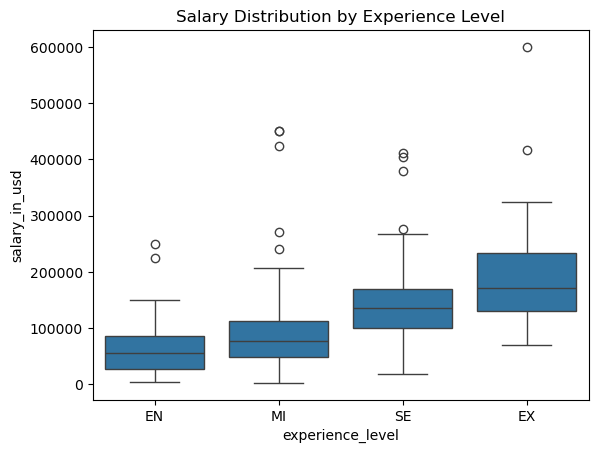

In [18]:
sns.boxplot(data=df, x='experience_level', y='salary_in_usd', order=['EN', 'MI', 'SE', 'EX'])
plt.title('Salary Distribution by Experience Level')
plt.show()

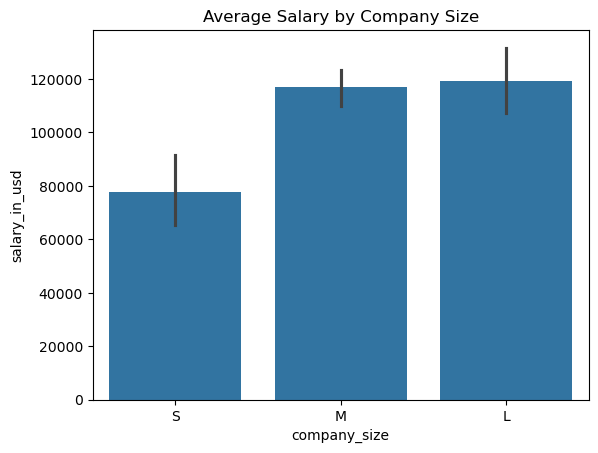

In [19]:
sns.barplot(data=df, x='company_size', y='salary_in_usd', order=['S', 'M', 'L'])
plt.title('Average Salary by Company Size')
plt.show()

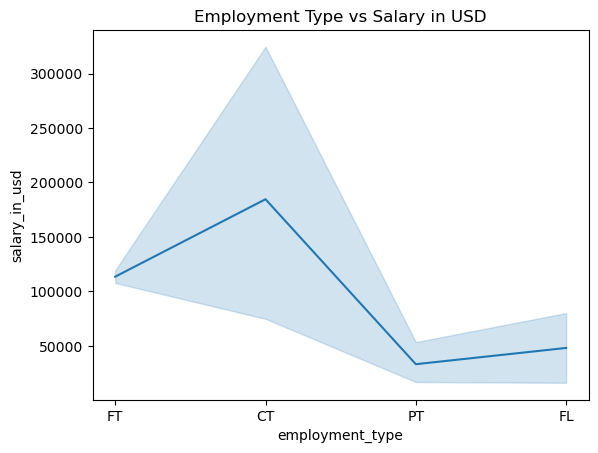

In [28]:
sns.lineplot(data=df, x='employment_type', y='salary_in_usd')
plt.title('Employment Type vs Salary in USD')
plt.show()

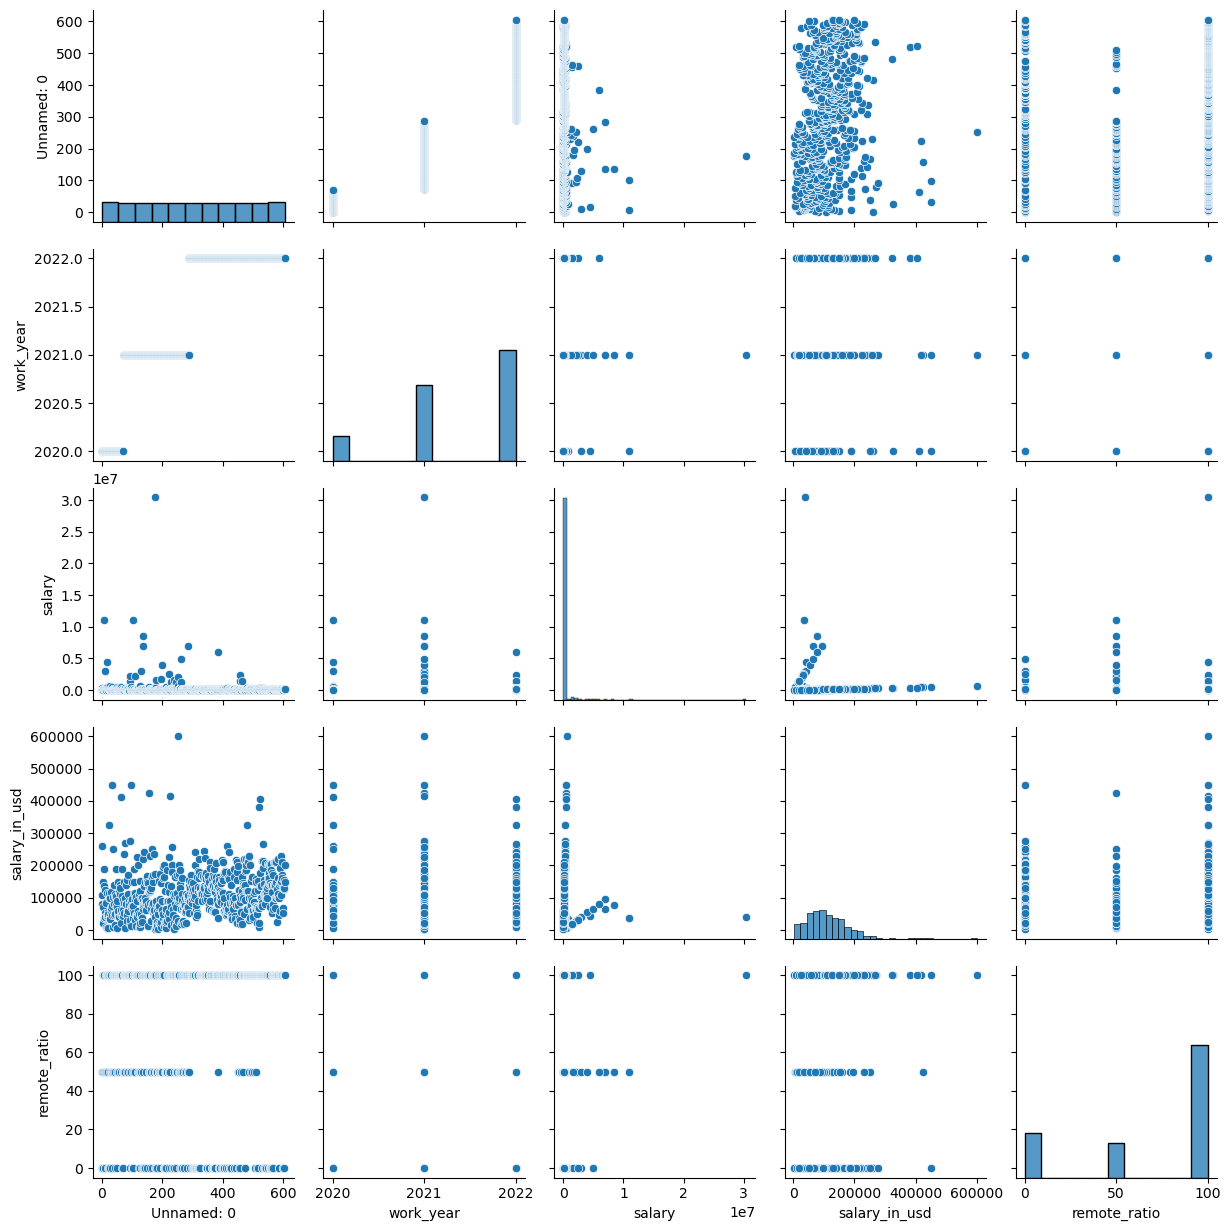

In [36]:
sns.pairplot(data=df)
plt.show()

# The CEO wants to know how much to pay a full-time Data Scientist to remain competitive, and how this differs for a US-based role versus an offshore one.

In [16]:
# 4. Answer CEO Question: Average Salary by Experience Level
avg_salary = df.groupby('experience_level')['salary_in_usd'].mean().reset_index()
print("\nAverage Salary by Experience Level:")
print(avg_salary)


Average Salary by Experience Level:
  experience_level  salary_in_usd
0               EN   61643.318182
1               EX  199392.038462
2               MI   87996.056338
3               SE  138617.292857


/var/folders/tt/vgx51bl93xd1z9pgrmcyxb180000gn/T/ipykernel_19325/1738152098.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_salary = df.groupby('experience_level')['salary_in_usd'].mean().reset_index()


In [56]:
# Subset data specifically for 'Data Scientist' roles
ds_roles = df[df['job_title'] == 'Data Scientist'].copy()

# Create a binary indicator for location (US vs Offshore)
ds_roles['location_type'] = ds_roles['company_location'].apply(lambda x: 'US' if x == 'US' else 'Offshore')

# Table: Calculate median salary by Experience and Location
summary_table = ds_roles.groupby(['experience_level', 'location_type'])['salary_in_usd'].median().unstack()
print("\nMedian Salary by Experience and Location")
print(summary_table)


Median Salary by Experience and Location
location_type     Offshore        US
experience_level                    
EN                 39958.0   95000.0
EX                     NaN       NaN
MI                 50000.0  118000.0
SE                 89487.5  150000.0


/var/folders/tt/vgx51bl93xd1z9pgrmcyxb180000gn/T/ipykernel_19325/3400813009.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary_table = ds_roles.groupby(['experience_level', 'location_type'])['salary_in_usd'].median().unstack()


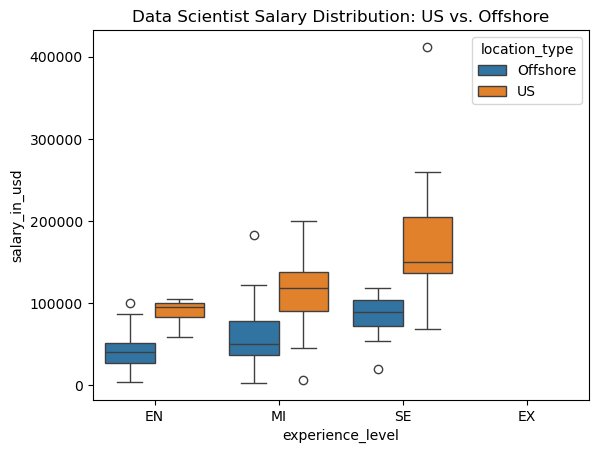

In [53]:
# Comparison of Salary Distributions
sns.boxplot(x='experience_level', y='salary_in_usd', hue='location_type', 
            data=ds_roles, order=['EN', 'MI', 'SE', 'EX'])
plt.title('Data Scientist Salary Distribution: US vs. Offshore')
plt.show()

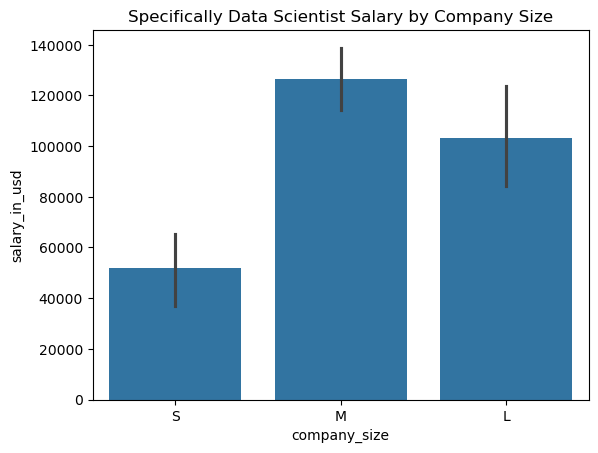

In [54]:
#Salary by Company Size for context
sns.barplot(x='company_size', y='salary_in_usd', data=ds_roles, order=['S', 'M', 'L'])
plt.title('Specifically Data Scientist Salary by Company Size')
plt.show()